# [Lab 5-3] GAN (Generative Adversarial Network) 기반 MNIST 손글씨 숫자 생성 실습
---
이 노트북에서는 Generative Adversarial Network (GAN)를 구현하여 MNIST 손글씨 숫자를 생성합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # GPU 사용 안함

import tensorflow as tf
from tensorflow.keras import layers

## 1. 데이터 준비

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_train = np.expand_dims(x_train, -1)

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

## 2. Generator 정의

In [3]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    model.add(layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding="same", use_bias=False, activation="tanh"))
    return model

generator = make_generator_model()
generator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 12544)             1254400   
                                                                 
 batch_normalization (BatchN  (None, 12544)            50176     
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 12544)             0         
                                                                 
 reshape (Reshape)           (None, 7, 7, 256)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 7, 7, 128)        819200    
 nspose)                                                         
                                                                 
 batch_normalization_1 (Batc  (None, 7, 7, 128)        5

## 3. Discriminator 정의

In [4]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding="same", input_shape=[28,28,1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

discriminator = make_discriminator_model()
discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 64)        1664      
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (None, 14, 14, 64)        0         
                                                                 
 dropout (Dropout)           (None, 14, 14, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 128)         204928    
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 7, 7, 128)         0         
                                                                 
 dropout_1 (Dropout)         (None, 7, 7, 128)         0         
                                                                 
 flatten (Flatten)           (None, 6272)             

## 4. 손실 함수와 Optimizer

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

## 5. 학습 루프 정의

In [6]:
EPOCHS = 30
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
        print(f"Epoch {epoch+1}, Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")

        generate_and_save_images(generator, epoch+1, seed)

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow(predictions[i,:,:,0]*127.5+127.5, cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

## 6. 모델 학습 실행

Epoch 1, Gen Loss: 1.0437, Disc Loss: 1.1616


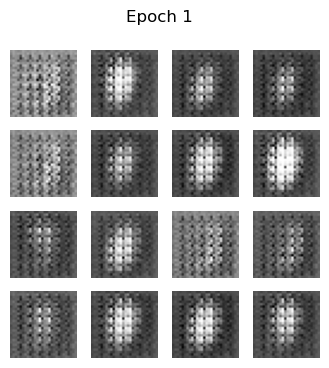

Epoch 2, Gen Loss: 0.8644, Disc Loss: 1.0800


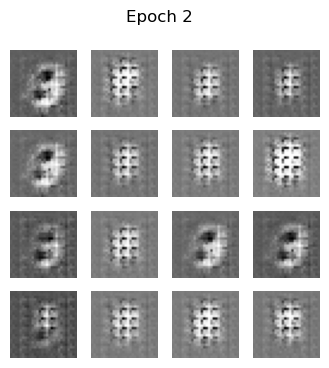

Epoch 3, Gen Loss: 0.7967, Disc Loss: 1.2290


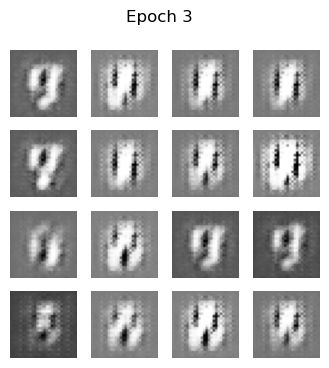

Epoch 4, Gen Loss: 1.1265, Disc Loss: 0.9425


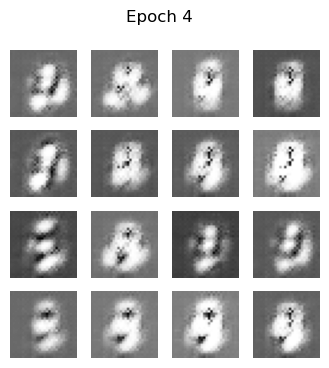

Epoch 5, Gen Loss: 1.0893, Disc Loss: 0.9736


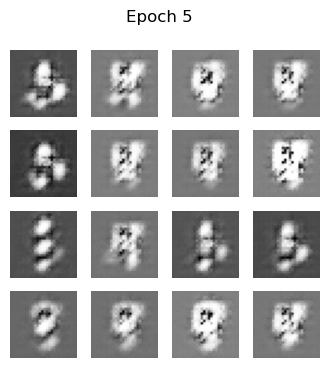

Epoch 6, Gen Loss: 1.3728, Disc Loss: 0.7877


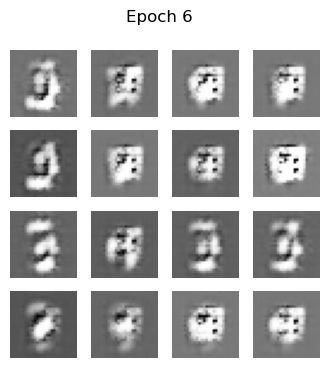

Epoch 7, Gen Loss: 1.8042, Disc Loss: 0.5568


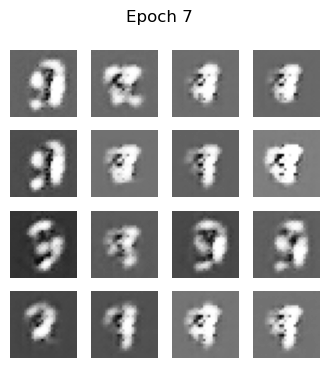

Epoch 8, Gen Loss: 1.5573, Disc Loss: 0.7790


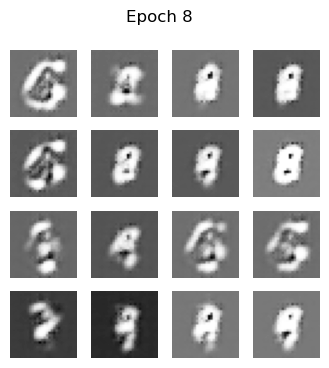

Epoch 9, Gen Loss: 1.6256, Disc Loss: 0.6812


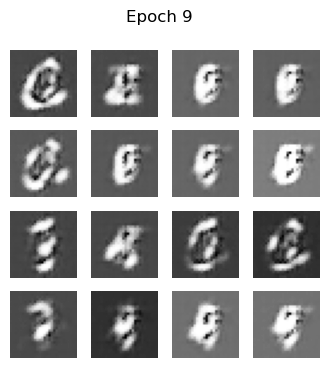

Epoch 10, Gen Loss: 2.0086, Disc Loss: 0.6805


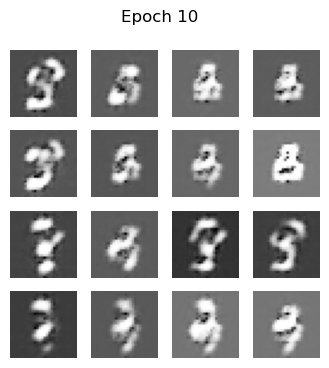

Epoch 11, Gen Loss: 1.9024, Disc Loss: 0.4968


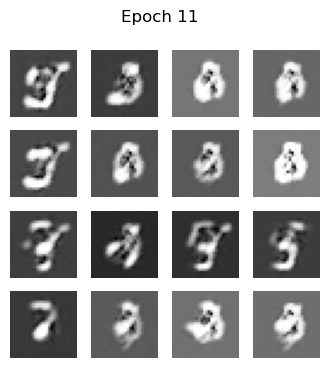

Epoch 12, Gen Loss: 1.7747, Disc Loss: 0.6999


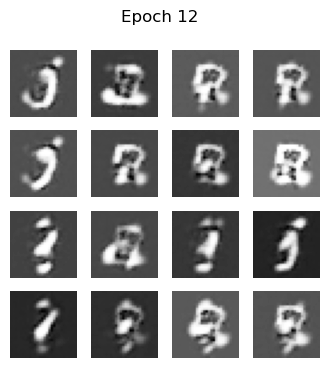

Epoch 13, Gen Loss: 2.1113, Disc Loss: 0.6625


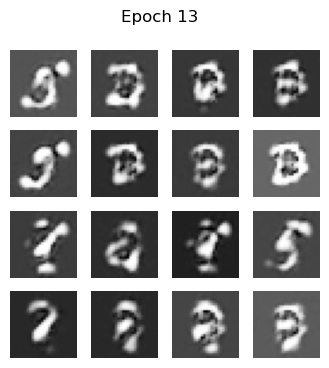

Epoch 14, Gen Loss: 2.0999, Disc Loss: 0.6580


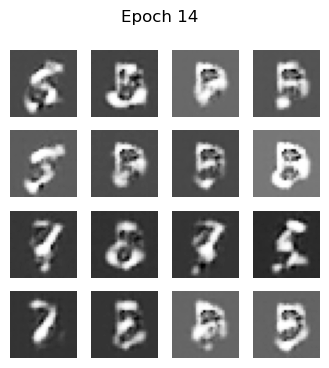

Epoch 15, Gen Loss: 2.0999, Disc Loss: 0.5515


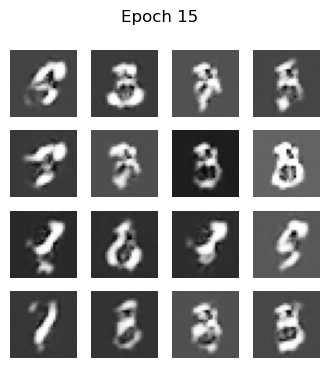

Epoch 16, Gen Loss: 2.4133, Disc Loss: 0.5829


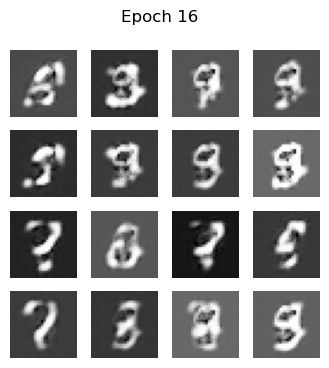

Epoch 17, Gen Loss: 2.3059, Disc Loss: 0.6572


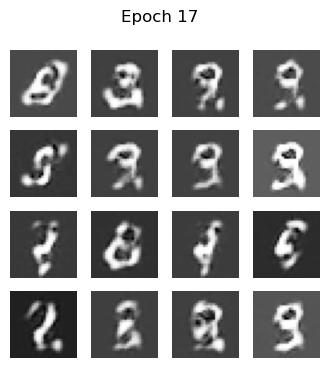

Epoch 18, Gen Loss: 2.0103, Disc Loss: 0.5845


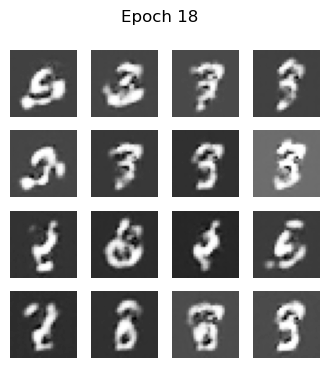

Epoch 19, Gen Loss: 2.1274, Disc Loss: 0.6160


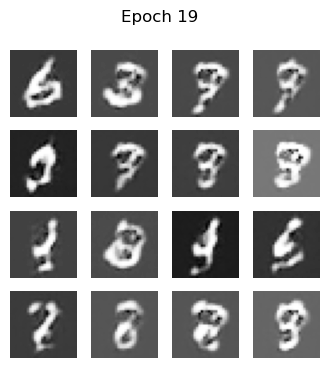

Epoch 20, Gen Loss: 2.0971, Disc Loss: 0.5708


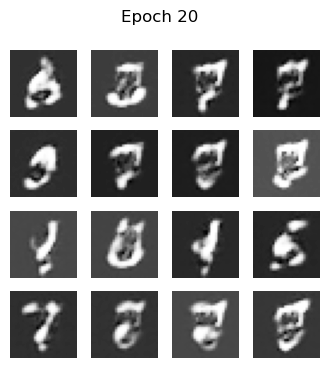

Epoch 21, Gen Loss: 2.4569, Disc Loss: 0.5647


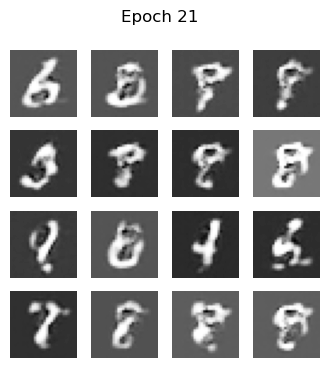

Epoch 22, Gen Loss: 2.1505, Disc Loss: 0.5190


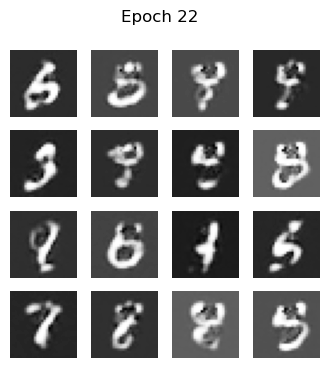

Epoch 23, Gen Loss: 2.4583, Disc Loss: 0.6291


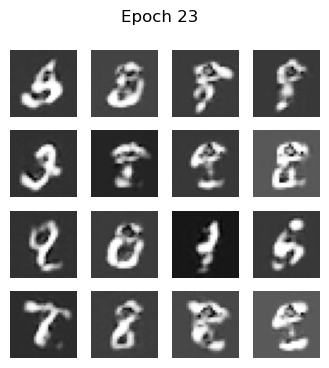

Epoch 24, Gen Loss: 2.1530, Disc Loss: 0.4842


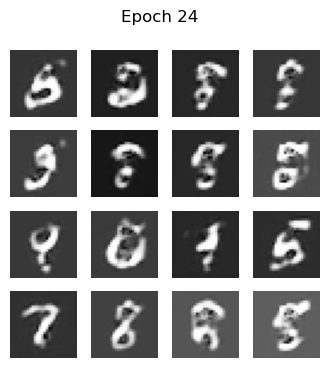

Epoch 25, Gen Loss: 2.0690, Disc Loss: 0.6837


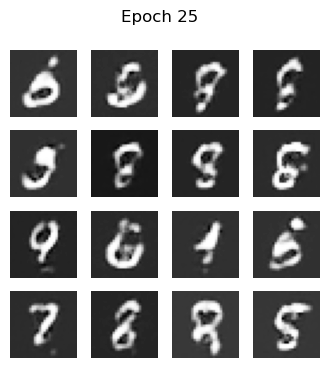

Epoch 26, Gen Loss: 2.3317, Disc Loss: 0.6302


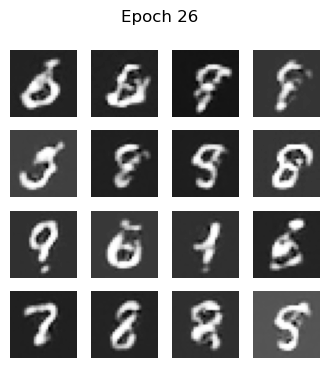

Epoch 27, Gen Loss: 2.3898, Disc Loss: 0.6092


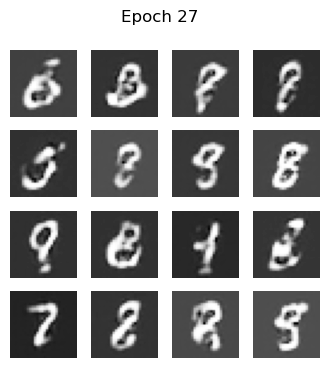

Epoch 28, Gen Loss: 2.2354, Disc Loss: 0.5412


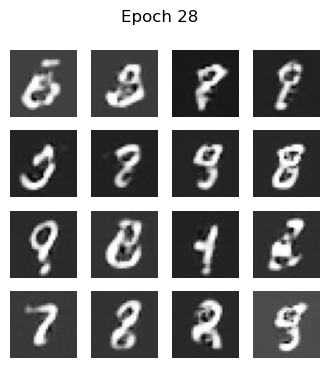

Epoch 29, Gen Loss: 2.0120, Disc Loss: 0.9327


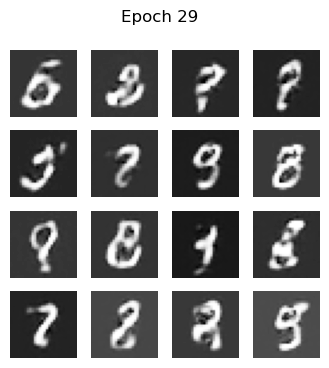

Epoch 30, Gen Loss: 1.9482, Disc Loss: 0.5837


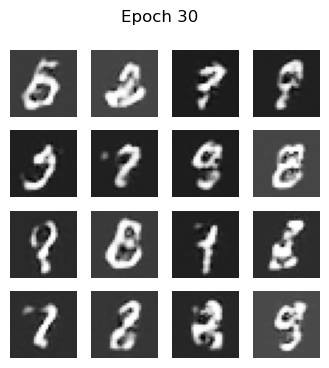

In [7]:
train(train_dataset, EPOCHS)

## 7. 최종 손글씨 생성

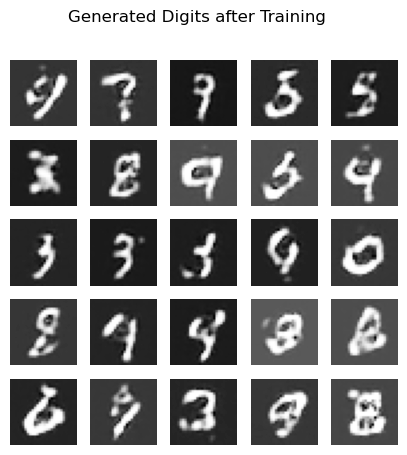

In [8]:
noise = tf.random.normal([25, noise_dim])
generated_images = generator(noise, training=False)

plt.figure(figsize=(5,5))
for i in range(generated_images.shape[0]):
    plt.subplot(5,5,i+1)
    plt.imshow(generated_images[i,:,:,0]*127.5+127.5, cmap="gray")
    plt.axis("off")
plt.suptitle("Generated Digits after Training")
plt.show()